<a href="https://colab.research.google.com/github/deekshdechamma/DL_skill_developer/blob/main/dl9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 9: Anchor-Free Object Detection (YOLOv8-style) Loss
Backpropagation
● Objective: Architect state-of-the-art multi-task object localization pipelines by tracking
regression outputs and classification predictions simultaneously.
● Required Tech Stack: PyTorch, OpenCV, NumPy, Matplotlib.
● Task Description: Students will write a custom loss-tracking module for an anchor-free
object detector. The module must implement Complete Intersection over Union (CIoU)
bounding box regression loss, compute classification loss, and handle complex assignment
strategies to match target labels with dynamic network outputs.

In [1]:
#Step 1 — Import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import cv2
import matplotlib.pyplot as plt

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

PyTorch Version: 2.11.0+cpu
CUDA Available: False


In [2]:
#Step 2 — Select device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


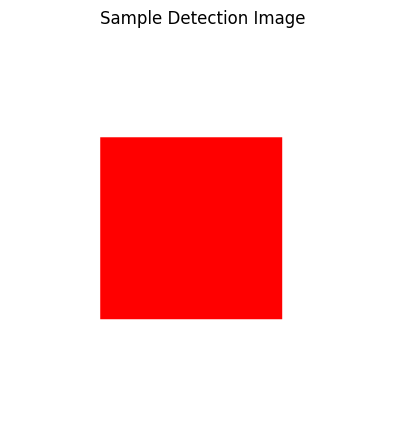

In [3]:
#Step 3 — Create sample image
IMG_SIZE = 256

image = np.ones(
    (IMG_SIZE, IMG_SIZE, 3),
    dtype=np.uint8
) * 255

# Draw object
cv2.rectangle(
    image,
    (60, 70),
    (180, 190),
    (0, 0, 255),
    -1
)

plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Sample Detection Image")
plt.axis("off")
plt.show()

In [5]:
#Step 4 — Define ground-truth bounding box
gt_box = torch.tensor(
    [[60.0, 70.0, 180.0, 190.0]],
    device=device
)

gt_class = torch.tensor(
    [0],
    dtype=torch.long,
    device=device
)

print("Ground Truth Box:", gt_box)
print("Ground Truth Class:", gt_class)

Ground Truth Box: tensor([[ 60.,  70., 180., 190.]])
Ground Truth Class: tensor([0])


In [6]:
#Step 5 — Bounding-box area
def box_area(box):

    width = (
        box[..., 2] - box[..., 0]
    ).clamp(min=0)

    height = (
        box[..., 3] - box[..., 1]
    ).clamp(min=0)

    return width * height

In [7]:
print("Bounding Box Area:", box_area(gt_box))

Bounding Box Area: tensor([14400.])


In [8]:
#Step 6 — IoU calculation
def calculate_iou(box1, box2, eps=1e-7):

    x1 = torch.max(
        box1[..., 0],
        box2[..., 0]
    )

    y1 = torch.max(
        box1[..., 1],
        box2[..., 1]
    )

    x2 = torch.min(
        box1[..., 2],
        box2[..., 2]
    )

    y2 = torch.min(
        box1[..., 3],
        box2[..., 3]
    )

    intersection = (
        (x2 - x1).clamp(min=0) *
        (y2 - y1).clamp(min=0)
    )

    area1 = box_area(box1)
    area2 = box_area(box2)

    union = (
        area1 +
        area2 -
        intersection
    )

    iou = intersection / (
        union + eps
    )

    return iou

In [9]:
pred_box = torch.tensor(
    [[65.0, 75.0, 175.0, 185.0]],
    device=device
)

iou = calculate_iou(
    pred_box,
    gt_box
)

print("IoU:", iou.item())

IoU: 0.8402777910232544


In [10]:
#Step 7 — Implement Complete IoU (CIoU)
def ciou(box1, box2, eps=1e-7):

    # IoU
    iou = calculate_iou(
        box1,
        box2,
        eps
    )

    # Predicted box center
    b1_cx = (
        box1[..., 0] +
        box1[..., 2]
    ) / 2

    b1_cy = (
        box1[..., 1] +
        box1[..., 3]
    ) / 2

    # Ground truth center
    b2_cx = (
        box2[..., 0] +
        box2[..., 2]
    ) / 2

    b2_cy = (
        box2[..., 1] +
        box2[..., 3]
    ) / 2

    # Center distance
    center_distance = (
        (b1_cx - b2_cx) ** 2 +
        (b1_cy - b2_cy) ** 2
    )

    # Smallest enclosing box
    enclose_x1 = torch.min(
        box1[..., 0],
        box2[..., 0]
    )

    enclose_y1 = torch.min(
        box1[..., 1],
        box2[..., 1]
    )

    enclose_x2 = torch.max(
        box1[..., 2],
        box2[..., 2]
    )

    enclose_y2 = torch.max(
        box1[..., 3],
        box2[..., 3]
    )

    diagonal_distance = (
        (enclose_x2 - enclose_x1) ** 2 +
        (enclose_y2 - enclose_y1) ** 2
    ) + eps

    # Width and height
    w1 = (
        box1[..., 2] -
        box1[..., 0]
    ).clamp(min=eps)

    h1 = (
        box1[..., 3] -
        box1[..., 1]
    ).clamp(min=eps)

    w2 = (
        box2[..., 2] -
        box2[..., 0]
    ).clamp(min=eps)

    h2 = (
        box2[..., 3] -
        box2[..., 1]
    ).clamp(min=eps)

    # Aspect-ratio penalty
    v = (
        4 /
        (np.pi ** 2)
    ) * (
        torch.atan(w2 / h2) -
        torch.atan(w1 / h1)
    ) ** 2

    with torch.no_grad():

        alpha = v / (
            1 -
            iou +
            v +
            eps
        )

    ciou_score = (
        iou
        -
        center_distance / diagonal_distance
        -
        alpha * v
    )

    return ciou_score

In [11]:
#Step 8 — Test CIoU
ciou_score = ciou(
    pred_box,
    gt_box
)

print(
    "CIoU Score:",
    ciou_score.item()
)

ciou_loss = (
    1 - ciou_score
).mean()

print(
    "CIoU Loss:",
    ciou_loss.item()
)

CIoU Score: 0.8402777910232544
CIoU Loss: 0.1597222089767456


In [12]:
#Step 9 — Create anchor-free grid points
def create_grid_points(
    feature_size,
    stride,
    device
):

    y, x = torch.meshgrid(
        torch.arange(
            feature_size,
            device=device
        ),
        torch.arange(
            feature_size,
            device=device
        ),
        indexing="ij"
    )

    grid = torch.stack(
        [
            (x + 0.5) * stride,
            (y + 0.5) * stride
        ],
        dim=-1
    )

    return grid.reshape(-1, 2).float()

In [13]:
FEATURE_SIZE = 16
STRIDE = IMG_SIZE // FEATURE_SIZE

grid_points = create_grid_points(
    FEATURE_SIZE,
    STRIDE,
    device
)

print(
    "Grid Points Shape:",
    grid_points.shape
)

print(
    "First 10 Grid Points:"
)

print(grid_points[:10])

Grid Points Shape: torch.Size([256, 2])
First 10 Grid Points:
tensor([[  8.,   8.],
        [ 24.,   8.],
        [ 40.,   8.],
        [ 56.,   8.],
        [ 72.,   8.],
        [ 88.,   8.],
        [104.,   8.],
        [120.,   8.],
        [136.,   8.],
        [152.,   8.]])


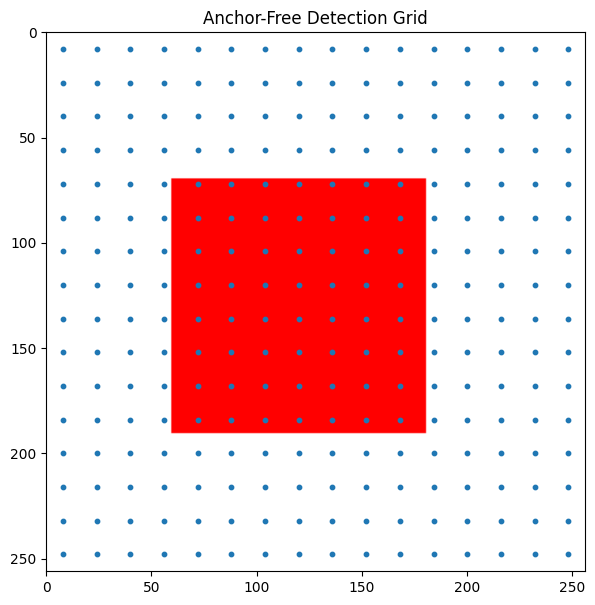

In [14]:
#Step 10 — Visualize anchor-free grid
plt.figure(figsize=(7, 7))

plt.imshow(
    cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )
)

points = (
    grid_points
    .detach()
    .cpu()
    .numpy()
)

plt.scatter(
    points[:, 0],
    points[:, 1],
    s=10
)

plt.title(
    "Anchor-Free Detection Grid"
)

plt.xlim(0, IMG_SIZE)
plt.ylim(IMG_SIZE, 0)

plt.show()

In [15]:
#Step 11 — Dynamic target assignment
def assign_targets(
    grid_points,
    gt_boxes
):

    assignments = []

    for gt_box in gt_boxes:

        x1, y1, x2, y2 = gt_box

        inside_x = (
            (grid_points[:, 0] >= x1) &
            (grid_points[:, 0] <= x2)
        )

        inside_y = (
            (grid_points[:, 1] >= y1) &
            (grid_points[:, 1] <= y2)
        )

        positive_mask = (
            inside_x &
            inside_y
        )

        assignments.append(
            positive_mask
        )

    return torch.stack(assignments)

In [16]:
assignment = assign_targets(
    grid_points,
    gt_box
)

print(
    "Assignment Shape:",
    assignment.shape
)

print(
    "Positive Grid Points:",
    assignment.sum().item()
)

Assignment Shape: torch.Size([1, 256])
Positive Grid Points: 56


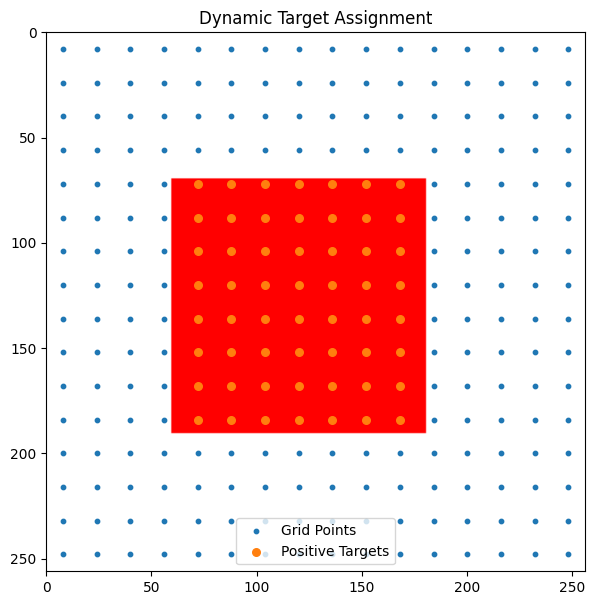

In [17]:
#Step 12 — Visualize positive assignments
positive_mask = (
    assignment[0]
    .detach()
    .cpu()
    .numpy()
)

plt.figure(figsize=(7, 7))

plt.imshow(
    cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )
)

plt.scatter(
    points[:, 0],
    points[:, 1],
    s=10,
    label="Grid Points"
)

plt.scatter(
    points[positive_mask, 0],
    points[positive_mask, 1],
    s=30,
    label="Positive Targets"
)

plt.legend()

plt.title(
    "Dynamic Target Assignment"
)

plt.xlim(0, IMG_SIZE)
plt.ylim(IMG_SIZE, 0)

plt.show()

In [18]:
#Step 13 — Create detection backbone
class DetectionBackbone(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Conv2d(
                3, 32,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(
                32, 64,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(
                64, 128,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(
                128, 256,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(256),
            nn.ReLU()
        )

    def forward(self, x):

        return self.network(x)

In [19]:
#Step 14 — Anchor-free detection head
class DetectionHead(nn.Module):

    def __init__(
        self,
        in_channels=256,
        num_classes=1
    ):

        super().__init__()

        self.bbox_head = nn.Conv2d(
            in_channels,
            4,
            kernel_size=1
        )

        self.class_head = nn.Conv2d(
            in_channels,
            num_classes,
            kernel_size=1
        )

    def forward(self, x):

        bbox = self.bbox_head(x)

        cls = self.class_head(x)

        return bbox, cls

In [24]:
class AnchorFreeDetector(nn.Module):

    def __init__(self, num_classes=1):

        super().__init__()

        self.backbone = DetectionBackbone()

        self.head = DetectionHead(
            256,
            num_classes
        )

    def forward(self, x):

        features = self.backbone(x)

        bbox, classification = self.head(features)

        return bbox, classification

In [21]:
model = AnchorFreeDetector(
    num_classes=1
).to(device)

print(model)

AnchorFreeDetector(
  (backbone): DetectionBackbone(
    (network): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): ReLU()
      (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (11): ReLU()
    )
  )
  (head): DetectionHead(
    (bbox_head): Conv2d(256, 4, kernel_size=(1, 1), stride=(1, 1))
    (class_head): Conv2d(256, 1, kernel_size=(1, 1), stride=(1, 1))


In [22]:
#Step 16 — Prepare image tensor
image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

image_tensor = torch.tensor(
    image_rgb,
    dtype=torch.float32
)

image_tensor = (
    image_tensor
    .permute(2, 0, 1)
    .unsqueeze(0)
)

image_tensor = (
    image_tensor / 255.0
).to(device)

print(
    "Input Shape:",
    image_tensor.shape
)

Input Shape: torch.Size([1, 3, 256, 256])


In [27]:
#Step 17 — Forward propagation
model = AnchorFreeDetector(
    num_classes=1
).to(device)

bbox_output, class_output = model(
    image_tensor
)

print(
    "BBox Output Shape:",
    bbox_output.shape
)

print(
    "Classification Output Shape:",
    class_output.shape
)

BBox Output Shape: torch.Size([1, 4, 16, 16])
Classification Output Shape: torch.Size([1, 1, 16, 16])


In [28]:
#Step 18 — Decode anchor-free bounding boxes
def decode_boxes(
    bbox_pred,
    grid_points
):

    # [B,4,H,W]
    bbox_pred = bbox_pred.permute(
        0, 2, 3, 1
    )

    bbox_pred = bbox_pred.reshape(
        bbox_pred.shape[0],
        -1,
        4
    )

    # Ensure distances are positive
    distances = F.softplus(
        bbox_pred
    )

    gx = grid_points[:, 0]
    gy = grid_points[:, 1]

    left = distances[..., 0]
    top = distances[..., 1]
    right = distances[..., 2]
    bottom = distances[..., 3]

    x1 = gx - left
    y1 = gy - top

    x2 = gx + right
    y2 = gy + bottom

    boxes = torch.stack(
        [x1, y1, x2, y2],
        dim=-1
    )

    return boxes

In [29]:
decoded_boxes = decode_boxes(
    bbox_output,
    grid_points
)

print(
    "Decoded Boxes:",
    decoded_boxes.shape
)

Decoded Boxes: torch.Size([1, 256, 4])


In [30]:
#Step 19 — Classification target
positive_mask = assignment[0]

classification_target = torch.zeros(
    len(grid_points),
    device=device
)

classification_target[
    positive_mask
] = 1.0

print(
    "Positive Targets:",
    classification_target.sum().item()
)

Positive Targets: 56.0


In [31]:
#Step 20 — Classification loss
classification_logits = (
    class_output
    .permute(0, 2, 3, 1)
    .reshape(-1)
)

classification_loss = (
    F.binary_cross_entropy_with_logits(
        classification_logits,
        classification_target
    )
)

print(
    "Classification Loss:",
    classification_loss.item()
)

Classification Loss: 0.7562278509140015


In [32]:
#Step 21 — Bounding-box regression loss
positive_boxes = (
    decoded_boxes[0][positive_mask]
)

target_boxes = (
    gt_box.expand(
        positive_boxes.shape[0],
        -1
    )
)

ciou_scores = ciou(
    positive_boxes,
    target_boxes
)

bbox_loss = (
    1 - ciou_scores
).mean()

print(
    "CIoU Bounding Box Loss:",
    bbox_loss.item()
)

CIoU Bounding Box Loss: 1.0822300910949707


In [33]:
#Step 22 — Custom YOLO-style loss module
class YOLOStyleLoss(nn.Module):

    def __init__(
        self,
        box_weight=7.5,
        cls_weight=0.5
    ):

        super().__init__()

        self.box_weight = box_weight
        self.cls_weight = cls_weight

    def forward(
        self,
        decoded_boxes,
        cls_logits,
        target_box,
        positive_mask
    ):

        # -------------------
        # Classification Loss
        # -------------------

        cls_target = torch.zeros_like(
            cls_logits
        )

        cls_target[
            positive_mask
        ] = 1.0

        cls_loss = (
            F.binary_cross_entropy_with_logits(
                cls_logits,
                cls_target
            )
        )

        # -------------------
        # CIoU Loss
        # -------------------

        pred_positive = (
            decoded_boxes[
                positive_mask
            ]
        )

        if pred_positive.shape[0] > 0:

            target_positive = (
                target_box.expand(
                    pred_positive.shape[0],
                    -1
                )
            )

            ciou_score = ciou(
                pred_positive,
                target_positive
            )

            box_loss = (
                1 - ciou_score
            ).mean()

        else:

            box_loss = torch.tensor(
                0.0,
                device=decoded_boxes.device
            )

        # -------------------
        # Total Loss
        # -------------------

        total_loss = (
            self.box_weight * box_loss
            +
            self.cls_weight * cls_loss
        )

        return (
            total_loss,
            box_loss,
            cls_loss
        )

In [34]:
#Step 23 — Create loss function
criterion = YOLOStyleLoss(
    box_weight=7.5,
    cls_weight=0.5
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [35]:
#Step 24 — Loss calculation
bbox_output, class_output = model(
    image_tensor
)

decoded_boxes = decode_boxes(
    bbox_output,
    grid_points
)

cls_logits = (
    class_output
    .permute(0, 2, 3, 1)
    .reshape(-1)
)

total_loss, box_loss, cls_loss = criterion(
    decoded_boxes[0],
    cls_logits,
    gt_box,
    positive_mask
)

print(
    "Total Loss:",
    total_loss.item()
)

print(
    "CIoU Loss:",
    box_loss.item()
)

print(
    "Classification Loss:",
    cls_loss.item()
)

Total Loss: 8.494839668273926
CIoU Loss: 1.0822300910949707
Classification Loss: 0.7562278509140015


In [36]:
#Step 25 — Backpropagation
optimizer.zero_grad()

total_loss.backward()

optimizer.step()

print(
    "Backpropagation completed successfully!"
)

Backpropagation completed successfully!


In [37]:
#Step 26 — Verify gradients
for name, parameter in model.named_parameters():

    if parameter.grad is not None:

        print(
            name,
            "Gradient Mean:",
            parameter.grad.abs().mean().item()
        )

backbone.network.0.weight Gradient Mean: 0.007862575352191925
backbone.network.0.bias Gradient Mean: 1.0791046634039958e-06
backbone.network.1.weight Gradient Mean: 0.007804790046066046
backbone.network.1.bias Gradient Mean: 0.007148184813559055
backbone.network.3.weight Gradient Mean: 0.005948697682470083
backbone.network.3.bias Gradient Mean: 5.099066768821103e-08
backbone.network.4.weight Gradient Mean: 0.002814127365127206
backbone.network.4.bias Gradient Mean: 0.0027622277848422527
backbone.network.6.weight Gradient Mean: 0.0034938002936542034
backbone.network.6.bias Gradient Mean: 7.561661519162044e-09
backbone.network.7.weight Gradient Mean: 0.0026218597777187824
backbone.network.7.bias Gradient Mean: 0.002344180829823017
backbone.network.9.weight Gradient Mean: 0.0024639321491122246
backbone.network.9.bias Gradient Mean: 1.5516927742709186e-09
backbone.network.10.weight Gradient Mean: 0.0015842755092307925
backbone.network.10.bias Gradient Mean: 0.002635883167386055
head.bbox_h

In [38]:
#Step 27 — Training loop
EPOCHS = 30

total_losses = []
box_losses = []
cls_losses = []

for epoch in range(EPOCHS):

    model.train()

    bbox_output, class_output = model(
        image_tensor
    )

    decoded_boxes = decode_boxes(
        bbox_output,
        grid_points
    )

    cls_logits = (
        class_output
        .permute(0, 2, 3, 1)
        .reshape(-1)
    )

    total_loss, box_loss, cls_loss = criterion(
        decoded_boxes[0],
        cls_logits,
        gt_box,
        positive_mask
    )

    optimizer.zero_grad()

    total_loss.backward()

    optimizer.step()

    total_losses.append(
        total_loss.item()
    )

    box_losses.append(
        box_loss.item()
    )

    cls_losses.append(
        cls_loss.item()
    )

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Total: {total_loss.item():.4f} | "
        f"CIoU: {box_loss.item():.4f} | "
        f"Cls: {cls_loss.item():.4f}"
    )

Epoch [1/30] Total: 8.2206 | CIoU: 1.0820 | Cls: 0.2107
Epoch [2/30] Total: 8.1777 | CIoU: 1.0818 | Cls: 0.1279
Epoch [3/30] Total: 8.1599 | CIoU: 1.0813 | Cls: 0.1006
Epoch [4/30] Total: 8.1503 | CIoU: 1.0809 | Cls: 0.0878
Epoch [5/30] Total: 8.1419 | CIoU: 1.0803 | Cls: 0.0793
Epoch [6/30] Total: 8.1339 | CIoU: 1.0797 | Cls: 0.0724
Epoch [7/30] Total: 8.1264 | CIoU: 1.0791 | Cls: 0.0668
Epoch [8/30] Total: 8.1192 | CIoU: 1.0784 | Cls: 0.0624
Epoch [9/30] Total: 8.1120 | CIoU: 1.0777 | Cls: 0.0589
Epoch [10/30] Total: 8.1047 | CIoU: 1.0769 | Cls: 0.0560
Epoch [11/30] Total: 8.0977 | CIoU: 1.0761 | Cls: 0.0539
Epoch [12/30] Total: 8.0907 | CIoU: 1.0753 | Cls: 0.0521
Epoch [13/30] Total: 8.0838 | CIoU: 1.0745 | Cls: 0.0502
Epoch [14/30] Total: 8.0770 | CIoU: 1.0737 | Cls: 0.0483
Epoch [15/30] Total: 8.0703 | CIoU: 1.0729 | Cls: 0.0465
Epoch [16/30] Total: 8.0637 | CIoU: 1.0722 | Cls: 0.0449
Epoch [17/30] Total: 8.0571 | CIoU: 1.0714 | Cls: 0.0433
Epoch [18/30] Total: 8.0505 | CIoU: 1.07

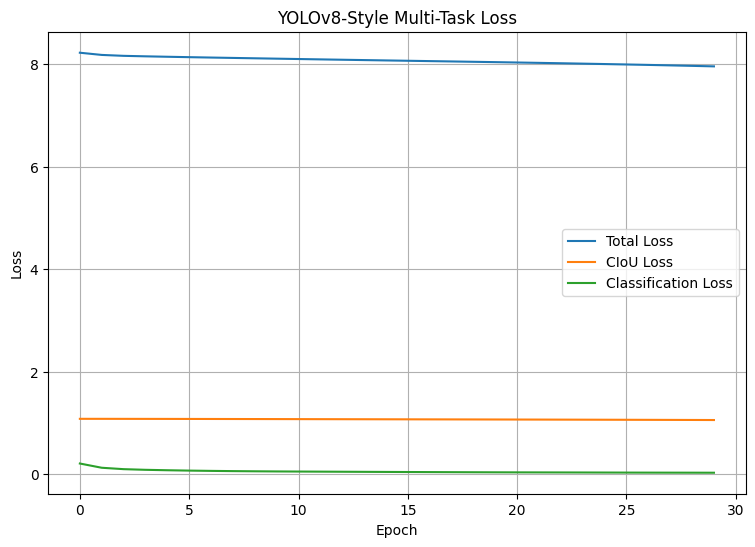

In [39]:
#Step 28 — Plot loss curves
plt.figure(figsize=(9, 6))

plt.plot(
    total_losses,
    label="Total Loss"
)

plt.plot(
    box_losses,
    label="CIoU Loss"
)

plt.plot(
    cls_losses,
    label="Classification Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "YOLOv8-Style Multi-Task Loss"
)

plt.legend()

plt.grid()

plt.show()

In [40]:
#Step 29 — Visualize prediction confidence
model.eval()

with torch.no_grad():

    bbox_output, class_output = model(
        image_tensor
    )

    decoded_boxes = decode_boxes(
        bbox_output,
        grid_points
    )

    confidence = torch.sigmoid(
        class_output
        .permute(0, 2, 3, 1)
        .reshape(-1)
    )

In [41]:
best_index = torch.argmax(
    confidence
)

best_confidence = confidence[
    best_index
]

best_box = decoded_boxes[
    0,
    best_index
]

print(
    "Best Confidence:",
    best_confidence.item()
)

print(
    "Predicted Box:",
    best_box
)

Best Confidence: 0.9475046992301941
Predicted Box: tensor([ 85.2029, 180.9599,  88.9618, 184.4388])


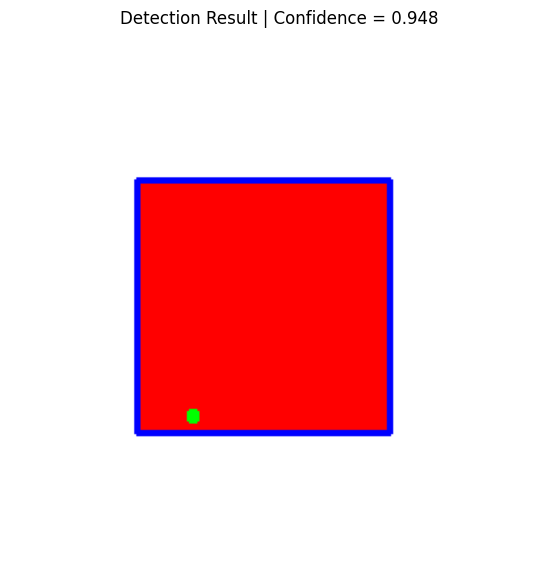

In [43]:
#Step 30 — Draw predicted bounding box
result = image.copy()

box = (
    best_box
    .detach()
    .cpu()
    .numpy()
)

x1, y1, x2, y2 = box

x1 = int(np.clip(x1, 0, IMG_SIZE - 1))
y1 = int(np.clip(y1, 0, IMG_SIZE - 1))
x2 = int(np.clip(x2, 0, IMG_SIZE - 1))
y2 = int(np.clip(y2, 0, IMG_SIZE - 1))

cv2.rectangle(
    result,
    (x1, y1),
    (x2, y2),
    (0, 255, 0),
    2
)

cv2.rectangle(
    result,
    (60, 70),
    (180, 190),
    (255, 0, 0),
    2
)

plt.figure(figsize=(7, 7))

plt.imshow(
    cv2.cvtColor(
        result,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    f"Detection Result | Confidence = {best_confidence.item():.3f}"
)

plt.axis("off")

plt.show()

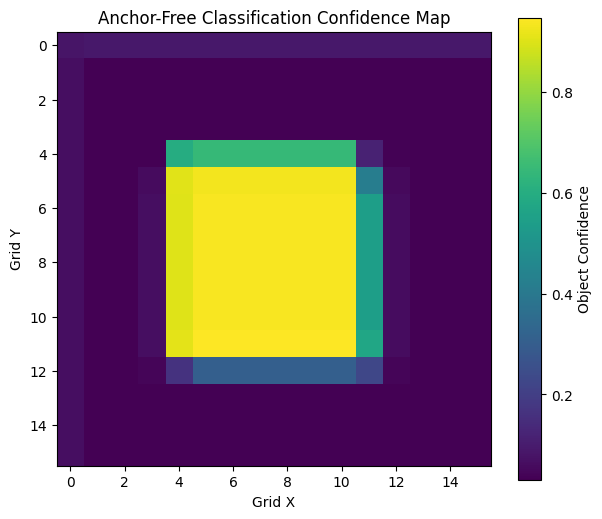

In [44]:
#Step 31 — Plot confidence heatmap
confidence_map = (
    confidence
    .reshape(
        FEATURE_SIZE,
        FEATURE_SIZE
    )
    .detach()
    .cpu()
    .numpy()
)

plt.figure(figsize=(7, 6))

plt.imshow(
    confidence_map,
    interpolation="nearest"
)

plt.colorbar(
    label="Object Confidence"
)

plt.title(
    "Anchor-Free Classification Confidence Map"
)

plt.xlabel("Grid X")
plt.ylabel("Grid Y")

plt.show()

In [45]:
#Step 32 — Save model
torch.save(
    model.state_dict(),
    "anchor_free_detector.pth"
)

print(
    "Model saved successfully!"
)

Model saved successfully!
